# Pokémon TCG — recurrent paper net evaluation

`paper_final` = recurrent V-Trace/PPO OSFP net, 5000 iterations. Source data:
`results/paper_eval.json` (`scripts/run_paper_eval.py`) and
`data/paperosfp/main/train.log`. All win rates are slot-swapped with Wilson 95% CI.

In [1]:
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "results").exists())
E = json.loads((ROOT / "results" / "paper_eval.json").read_text())
M = E["matches"]
print("final:", E["final"])
print("phase5d ref:", E["phase5d"])
print("matches:", len(M))

final: /home/sakano/git/kaggle-pokemon/data/paperosfp/main/paper_final.npz
phase5d ref: /home/sakano/git/kaggle-pokemon/data/jointosfp/run2/jointiter_649.npz
matches: 18


## Training curve — gate win rate vs iteration (vs metal_aggro)

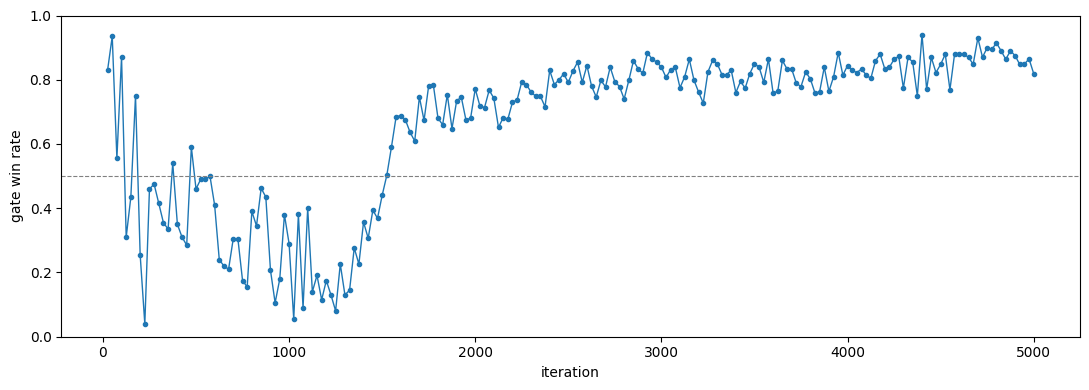

In [2]:
log = (ROOT / "data/paperosfp/main/train.log").read_text().splitlines()
gate = []
for ln in log:
    m = re.search(r"paperiter (\d+).*gate=([0-9.]+)", ln)
    if m:
        gate.append((int(m.group(1)), float(m.group(2))))
gx = [a for a, _ in gate]
gy = [b for _, b in gate]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gx, gy, marker=".", lw=1)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_xlabel("iteration")
ax.set_ylabel("gate win rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Head-to-head vs baselines

In [3]:
labels = [
    ("vs_phase5d", "vs Phase-5d (full: own deck + play)"),
    ("vs_greedy_samedeck", "vs greedy (shared deck: play only)"),
    ("vs_random_samedeck", "vs random (shared deck: play only)"),
]
rows = [
    [lbl, round(M[k]["winrate"], 3),
     f"[{M[k]['ci_lo']:.3f}, {M[k]['ci_hi']:.3f}]", M[k]["decisive"],
     round(M[k]["avg_turns"], 1), round(M[k]["avg_move_ms"], 3)]
    for k, lbl in labels if k in M
]
pd.DataFrame(
    rows,
    columns=["matchup", "winrate", "95% CI", "decisive", "avg turns", "avg move ms"],
)

,matchup,winrate,95% CI,decisive,avg turns,avg move ms
0,vs Phase-5d (full: own deck + play),0.960,"[0.931, 0.977]",300,30.8,0.542
1,vs greedy (shared deck: play only),0.325,"[0.264, 0.393]",200,13.8,0.256
2,vs random (shared deck: play only),0.835,"[0.777, 0.880]",200,23.4,0.251


## Checkpoint progression — win rate vs Phase-5d by iteration

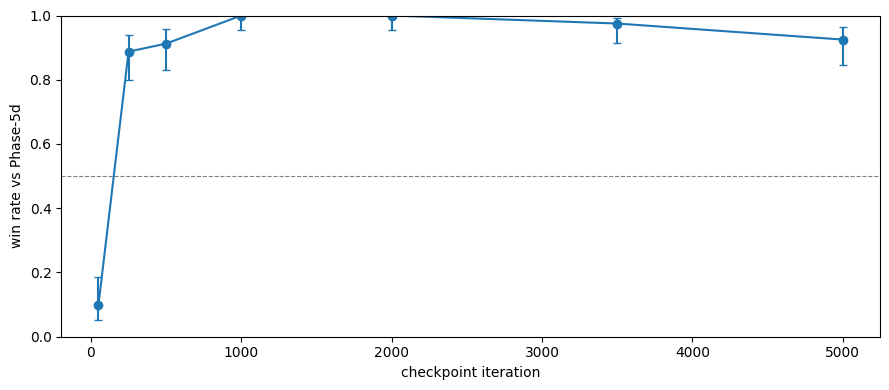

In [4]:
its = [it for it in E["checkpoint_iters"] if f"ckpt_{it}" in M]
ys = np.array([M[f"ckpt_{it}"]["winrate"] for it in its])
lo = np.array([M[f"ckpt_{it}"]["ci_lo"] for it in its])
hi = np.array([M[f"ckpt_{it}"]["ci_hi"] for it in its])
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(
    its, ys, yerr=[np.clip(ys - lo, 0, None), np.clip(hi - ys, 0, None)],
    marker="o", capsize=3,
)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_ylim(0, 1)
ax.set_xlabel("checkpoint iteration")
ax.set_ylabel("win rate vs Phase-5d")
plt.tight_layout()
plt.show()

## Gauntlet — the net's deck vs each meta archetype (greedy-piloted)

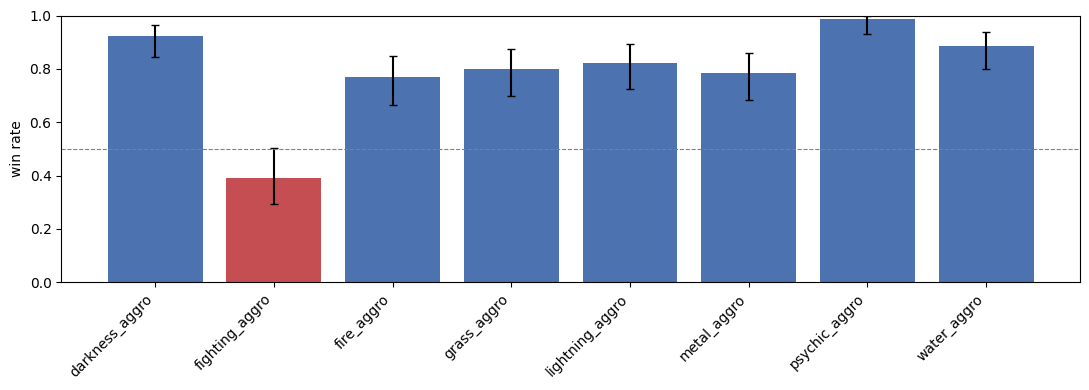

,meta deck,winrate,95% CI,decisive
0,darkness_aggro,0.925,"[0.846, 0.965]",80
1,fighting_aggro,0.392,"[0.292, 0.503]",79
2,fire_aggro,0.769,"[0.664, 0.849]",78
3,grass_aggro,0.800,"[0.700, 0.873]",80
4,lightning_aggro,0.823,"[0.724, 0.891]",79
5,metal_aggro,0.785,"[0.682, 0.861]",79
6,psychic_aggro,0.988,"[0.933, 0.998]",80
7,water_aggro,0.887,"[0.800, 0.940]",80


In [5]:
g = sorted((k.replace("gauntlet_", ""), M[k]) for k in M if k.startswith("gauntlet_"))
names = [n for n, _ in g]
wr = np.array([s["winrate"] for _, s in g])
lo = np.array([s["ci_lo"] for _, s in g])
hi = np.array([s["ci_hi"] for _, s in g])
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(names, wr, color=["#4c72b0" if w >= 0.5 else "#c44e52" for w in wr])
ax.errorbar(
    names, wr, yerr=[np.clip(wr - lo, 0, None), np.clip(hi - wr, 0, None)],
    fmt="none", ecolor="black", capsize=3,
)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel("win rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
pd.DataFrame(
    [(n, round(s["winrate"], 3), f"[{s['ci_lo']:.3f}, {s['ci_hi']:.3f}]", s["decisive"])
     for n, s in g],
    columns=["meta deck", "winrate", "95% CI", "decisive"],
)

## Deck composition (greedy build) + top cards

In [6]:
d = E["deck"]
print("type composition:", d["greedy_comp"], " | distinct:", d["greedy_distinct"])
pd.DataFrame(d["greedy_top"], columns=["card id", "copies"])

type composition: {'trainer': 22, 'pokemon': 16, 'energy': 22}  | distinct: 18


,card id,copies
0,6,11
1,24,4
2,1227,4
3,15,4
4,1204,4
5,1199,4
6,14,4
7,1006,4


## Deck composition over training iterations

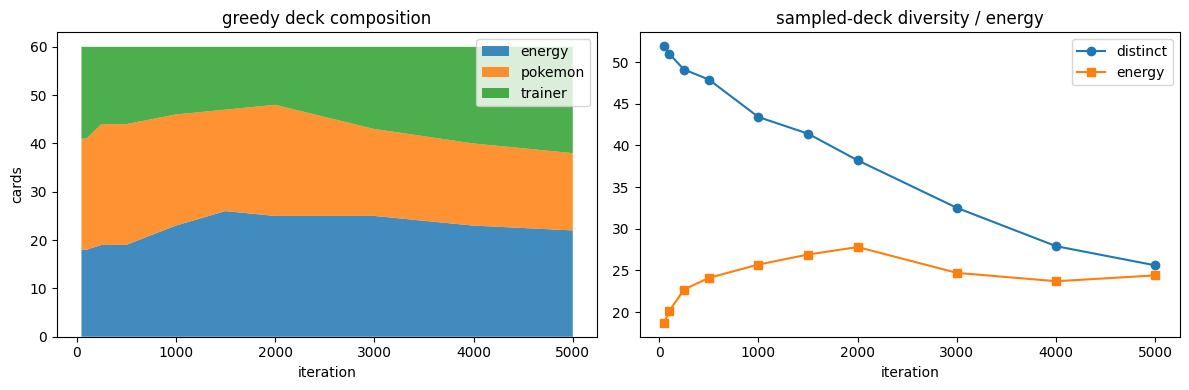

,iter,energy,pokemon,trainer,distinct,sampled_energy,sampled_distinct
0,50,18,23,19,17,18.7,51.9
1,100,18,23,19,16,20.1,51.0
2,250,19,25,16,16,22.7,49.1
3,500,19,25,16,16,24.1,47.9
4,1000,23,23,14,16,25.7,43.4
5,1500,26,21,13,18,26.9,41.4
6,2000,25,23,12,17,27.8,38.2
7,3000,25,18,17,18,24.7,32.5
8,4000,23,17,20,18,23.7,27.9
9,5000,22,16,22,21,24.4,25.6


In [7]:
ev = E.get("deck_evolution", [])
its = [r["iter"] for r in ev]
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].stackplot(
    its, [r["energy"] for r in ev], [r["pokemon"] for r in ev],
    [r["trainer"] for r in ev], labels=["energy", "pokemon", "trainer"], alpha=0.85,
)
axs[0].set_title("greedy deck composition")
axs[0].set_xlabel("iteration")
axs[0].set_ylabel("cards")
axs[0].legend(loc="upper right")
axs[1].plot(its, [r["sampled_distinct"] for r in ev], marker="o", label="distinct")
axs[1].plot(its, [r["sampled_energy"] for r in ev], marker="s", label="energy")
axs[1].set_title("sampled-deck diversity / energy")
axs[1].set_xlabel("iteration")
axs[1].legend()
plt.tight_layout()
plt.show()
pd.DataFrame(ev)

## Sampled-deck diversity (final net, 30 samples)

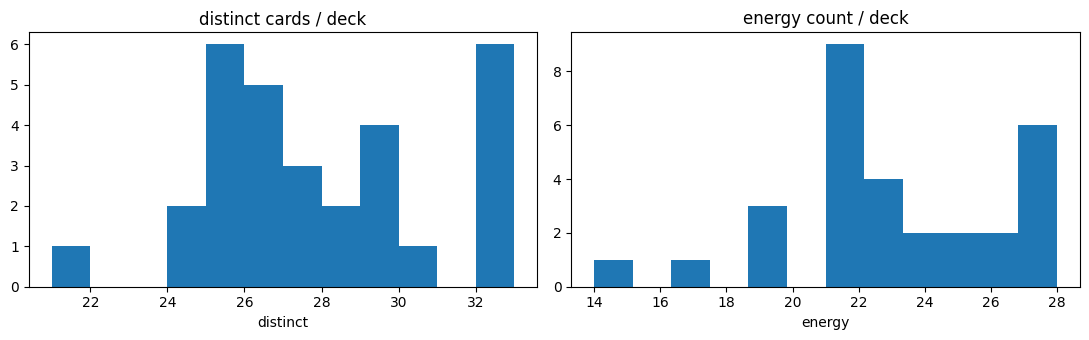

In [8]:
d = E["deck"]
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
axs[0].hist(d["sampled_distinct"], bins=12)
axs[0].set_title("distinct cards / deck")
axs[0].set_xlabel("distinct")
axs[1].hist(d["sampled_energy"], bins=12)
axs[1].set_title("energy count / deck")
axs[1].set_xlabel("energy")
plt.tight_layout()
plt.show()

## Inference cost (per move, recurrent serving)

In [9]:
rows = [
    [k, round(M[k]["avg_move_ms"], 3), round(M[k]["max_move_ms"], 1)]
    for k in ("vs_phase5d", "vs_greedy_samedeck", "vs_random_samedeck") if k in M
]
pd.DataFrame(rows, columns=["match", "avg move ms", "max move ms"])

,match,avg move ms,max move ms
0,vs_phase5d,0.542,68.5
1,vs_greedy_samedeck,0.256,16.6
2,vs_random_samedeck,0.251,23.9


## Deck vs play decomposition (2x2) + mirror

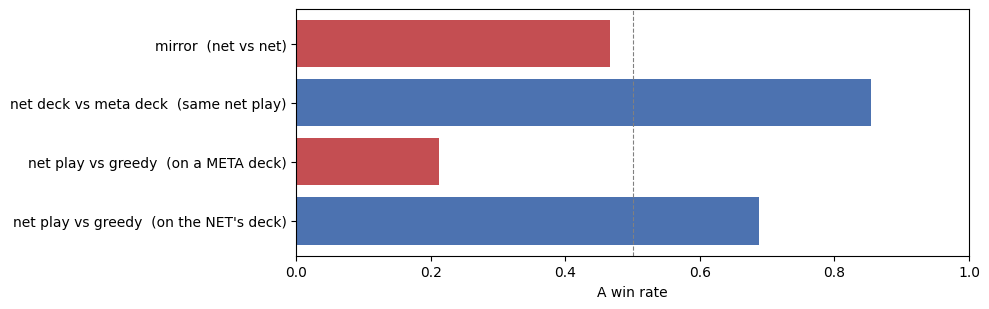

,matchup,A winrate,95% CI,decisive
0,net play vs greedy (on the NET's deck),0.688,"[0.612, 0.755]",157
1,net play vs greedy (on a META deck),0.212,"[0.156, 0.282]",160
2,net deck vs meta deck (same net play),0.854,"[0.791, 0.901]",158
3,mirror (net vs net),0.467,"[0.39, 0.546]",152


In [10]:
A = json.loads((ROOT / "results" / "paper_analysis.json").read_text())
mu = A["matchups"]
labels = {
    "play_net_vs_greedy_on_netdeck": "net play vs greedy  (on the NET's deck)",
    "play_net_vs_greedy_on_metadeck": "net play vs greedy  (on a META deck)",
    "deck_net_vs_meta_netplay": "net deck vs meta deck  (same net play)",
    "mirror": "mirror  (net vs net)",
}
ks = list(labels)
wr = [mu[k]["winrate"] for k in ks]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.barh([labels[k] for k in ks], wr,
        color=["#4c72b0" if w >= 0.5 else "#c44e52" for w in wr])
ax.axvline(0.5, color="gray", ls="--", lw=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("A win rate")
plt.tight_layout()
plt.show()
pd.DataFrame(
    [(labels[k], mu[k]["winrate"], f"[{mu[k]['ci'][0]}, {mu[k]['ci'][1]}]",
      mu[k]["decisive"]) for k in ks],
    columns=["matchup", "A winrate", "95% CI", "decisive"],
)

## Co-evolution — deck x play 2x2 (round-6 vs init play)

`results/coevo_2x2.json` (`scripts/coevo_2x2.py`). The 2x2 cells are **pilot vs greedy
with both sides on the same deck**, so the deck is controlled *within* a cell and the
win rate isolates play; compare **across a row** (same deck, swap the pilot) — `round6`
> `init` means co-evolved play is stronger with the deck held fixed. The **meta-deck
row** is the key test (net piloting a deck it did **not** design — the cure for
deck-specialised play). The two **duels** below are `round6` play vs `init` play on the
*same* deck (most sensitive play delta; `duel_metadeck` cross-checks `eval_paper_vs`).

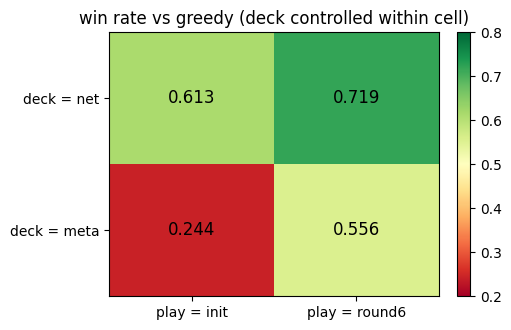

vs-greedy play delta  (net deck):  +0.106
vs-greedy play delta  (meta deck): +0.312
duel_netdeck   round6 vs init: 0.506 CI[0.43, 0.583]  (>0.5 = round6 play better)
duel_metadeck  round6 vs init: 0.850 CI[0.787, 0.897]  (>0.5 = round6 play better)


In [11]:
P = ROOT / "results" / "coevo_2x2.json"
if P.exists():
    C = json.loads(P.read_text())
    mu = C["matchups"]
    grid = [["init_play_netdeck", "final_play_netdeck"],
            ["init_play_metadeck", "final_play_metadeck"]]
    wr = np.array([[mu[c]["winrate"] for c in row] for row in grid])
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    im = ax.imshow(wr, cmap="RdYlGn", vmin=0.2, vmax=0.8, aspect="auto")
    ax.set_xticks([0, 1], ["play = init", "play = round6"])
    ax.set_yticks([0, 1], ["deck = net", "deck = meta"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{wr[i, j]:.3f}", ha="center", va="center", fontsize=12)
    ax.set_title("win rate vs greedy (deck controlled within cell)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()
    rows = [(k, v["winrate"], f"[{v['ci'][0]}, {v['ci'][1]}]", v["decisive"])
            for k, v in mu.items()]
    disp = pd.DataFrame(rows, columns=["matchup", "winrate", "95% CI", "decisive"])
    d_net = (mu["final_play_netdeck"]["winrate"]
             - mu["init_play_netdeck"]["winrate"])
    d_meta = (mu["final_play_metadeck"]["winrate"]
              - mu["init_play_metadeck"]["winrate"])
    print(f"vs-greedy play delta  (net deck):  {d_net:+.3f}")
    print(f"vs-greedy play delta  (meta deck): {d_meta:+.3f}")
    for d in ("duel_netdeck", "duel_metadeck"):
        if d in mu:
            v = mu[d]
            print(f"{d:14s} round6 vs init: {v['winrate']:.3f} "
                  f"CI[{v['ci'][0]}, {v['ci'][1]}]  (>0.5 = round6 play better)")
    disp
else:
    print("results/coevo_2x2.json not found -- run scripts/coevo_2x2.py")

## Co-evolution — play-strength trajectory (round-robin Elo, pure play)

`results/coevo_strength.json` (`scripts/coevo_strength.py`). `init` + `r1..r6` play a
round-robin **all piloting the same fixed meta deck**, so the Bradley-Terry Elo is
*pure play* (deck held constant). The **slope** is the decision signal: still climbing
→ more rounds help; flat → plateau, switch levers. The win matrix exposes intransitivity
(rock-paper-scissors) that a single rating hides.

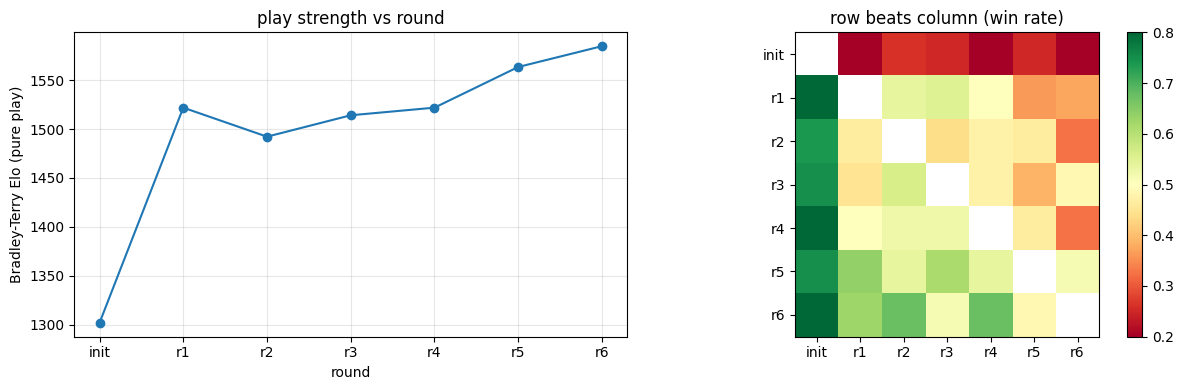

Elo spread: 283.1


In [12]:
P = ROOT / "results" / "coevo_strength.json"
if P.exists():
    S = json.loads(P.read_text())
    names, elo = S["names"], S["elo"]
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(range(len(names)), elo, marker="o")
    axs[0].set_xticks(range(len(names)), names)
    axs[0].set_xlabel("round")
    axs[0].set_ylabel("Bradley-Terry Elo (pure play)")
    axs[0].set_title("play strength vs round")
    axs[0].grid(alpha=0.3)
    wm = np.array([[np.nan if x is None else x for x in row]
                   for row in S["win_matrix"]])
    im = axs[1].imshow(wm, cmap="RdYlGn", vmin=0.2, vmax=0.8)
    axs[1].set_xticks(range(len(names)), names)
    axs[1].set_yticks(range(len(names)), names)
    axs[1].set_title("row beats column (win rate)")
    fig.colorbar(im, ax=axs[1], fraction=0.046)
    plt.tight_layout()
    plt.show()
    disp = pd.DataFrame({"round": names, "elo": elo})
    print("Elo spread:", round(max(elo) - min(elo), 1))
    disp
else:
    print("results/coevo_strength.json not found -- run scripts/coevo_strength.py")

## Co-evolution — QD archive evolution across rounds

Direct from `data/qdcoevo/run2/round_*/qd_archive.json`. Tracks whether the deck
**diversity** holds up (one of the two failure modes co-evo targets — the archive must
not collapse) and how fitness (win rate vs the gauntlet, *under the current play net*)
moves. Falling best-fitness while coverage holds = decks becoming less individually
dominant as play generalises, **not** collapse. The colour x energy grids show which
niches are filled in the first vs last round.

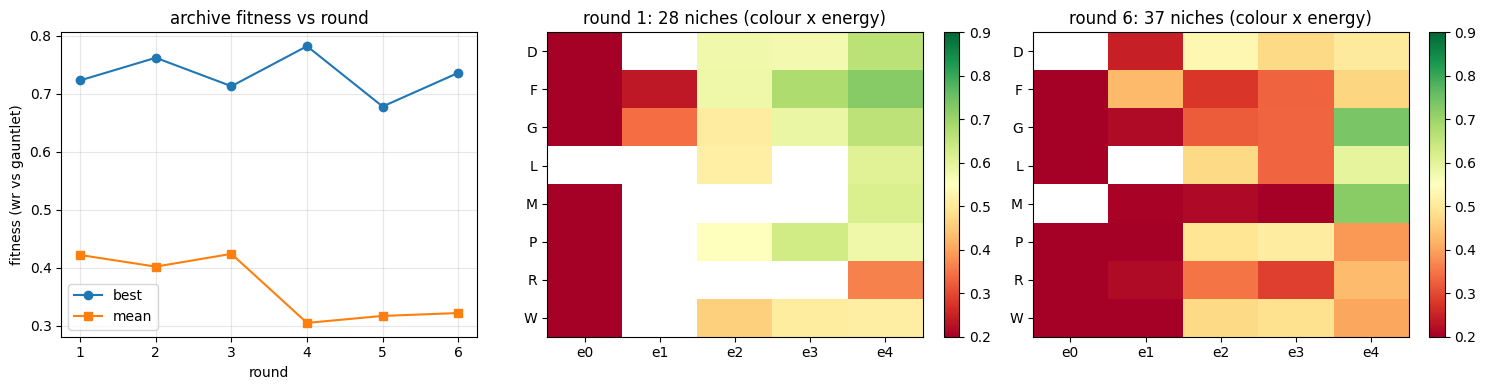

In [13]:
rows = []
grids = {}
for r in range(1, 7):
    p = ROOT / f"data/qdcoevo/run2/round_{r}/qd_archive.json"
    if not p.exists():
        continue
    cells = json.loads(p.read_text())["cells"]
    fits = [c["fitness"] for c in cells if c.get("fitness") is not None]
    rows.append({"round": r, "niches": len(cells),
                 "best": round(max(fits), 3),
                 "mean": round(sum(fits) / len(fits), 3)})
    grids[r] = {(c["descriptor"][0], c["descriptor"][1]): c["fitness"] for c in cells}
if rows:
    rdf = pd.DataFrame(rows)
    colours = sorted({k[0] for g in grids.values() for k in g})
    bins = list(range(5))
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].plot(rdf["round"], rdf["best"], marker="o", label="best")
    axs[0].plot(rdf["round"], rdf["mean"], marker="s", label="mean")
    axs[0].set_xlabel("round")
    axs[0].set_ylabel("fitness (wr vs gauntlet)")
    axs[0].set_title("archive fitness vs round")
    axs[0].legend()
    axs[0].grid(alpha=0.3)
    for ax, r in ((axs[1], min(grids)), (axs[2], max(grids))):
        grid = np.full((len(colours), len(bins)), np.nan)
        for (col, b), f in grids[r].items():
            grid[colours.index(col), b] = f
        im = ax.imshow(grid, cmap="RdYlGn", vmin=0.2, vmax=0.9, aspect="auto")
        ax.set_xticks(bins, [f"e{b}" for b in bins])
        ax.set_yticks(range(len(colours)), colours)
        ax.set_title(f"round {r}: {len(grids[r])} niches (colour x energy)")
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()
    rdf

## Co-evolution — round-6 vs init diagnostics (did the *evaluator* improve?)

`results/paper_analysis.json` (init) vs `results/coevo_round6_analysis.json`
(`analyze_paper_net.py --net <round6>`). The value head is the leaf evaluator a
future inference-time search would lean on — if co-evo left it flat/worse, search (not
more self-play) is the lever for play. Slot bias / entropy / game-length included.

In [14]:
I = json.loads((ROOT / "results" / "paper_analysis.json").read_text())
R = json.loads((ROOT / "results" / "coevo_round6_analysis.json").read_text())
vi, vr = I["value_calibration"], R["value_calibration"]
ei, er = I["policy_entropy"], R["policy_entropy"]
li, lr = I["loss_cause"], R["loss_cause"]
rows = [
    ("value sign-acc (overall)", vi["sign_accuracy"], vr["sign_accuracy"]),
    ("value sign-acc (early)", vi["early_game"], vr["early_game"]),
    ("value sign-acc (late)", vi["late_game"], vr["late_game"]),
    ("value mean|v|", vi["mean_abs_value"], vr["mean_abs_value"]),
    ("policy entropy (mean)", ei["mean"], er["mean"]),
    ("draw rate", li["draw_rate"], lr["draw_rate"]),
    ("avg win turns", li["avg_win_turns"], lr["avg_win_turns"]),
    ("avg loss turns", li["avg_loss_turns"], lr["avg_loss_turns"]),
]
df = pd.DataFrame(rows, columns=["metric", "init", "round6"])
df["delta"] = (df["round6"] - df["init"]).round(3)
df

,metric,init,round6,delta
0,value sign-acc (overall),0.671,0.668,-0.003
1,value sign-acc (early),0.597,0.528,-0.069
2,value sign-acc (late),0.757,0.813,0.056
3,value mean|v|,0.399,0.384,-0.015
4,policy entropy (mean),0.691,0.715,0.024
5,draw rate,0.020,0.000,-0.020
6,avg win turns,18.100,11.400,-6.700
7,avg loss turns,16.400,9.500,-6.900


## Diagnostics — value calibration, loss-cause, slot bias, policy entropy

In [15]:
A = json.loads((ROOT / "results" / "paper_analysis.json").read_text())
vc, lc, sb, pe = (A["value_calibration"], A["loss_cause"], A["slot_bias"],
                  A["policy_entropy"])
pd.DataFrame([
    ("value sign-acc (overall / early / late)",
     f"{vc['sign_accuracy']} / {vc['early_game']} / {vc['late_game']}"),
    ("value mean|v|", vc["mean_abs_value"]),
    ("abort / draw rate", f"{lc['abort_rate']} / {lc['draw_rate']}"),
    ("avg turns (win / loss)", f"{lc['avg_win_turns']} / {lc['avg_loss_turns']}"),
    ("mirror winrate (first / second)",
     f"{sb['mirror_first_winrate']} / {sb['mirror_second_winrate']}"),
    ("policy entropy (mean / median)", f"{pe['mean']} / {pe['median']}"),
], columns=["metric", "value"])

,metric,value
0,value sign-acc (overall / early / late),0.671 / 0.597 / 0.757
1,value mean|v|,0.399
2,abort / draw rate,0.0 / 0.02
3,avg turns (win / loss),18.1 / 16.4
4,mirror winrate (first / second),0.425 / 0.463
5,policy entropy (mean / median),0.691 / 0.659


## Strength over iterations — checkpoint round-robin (Bradley-Terry Elo)

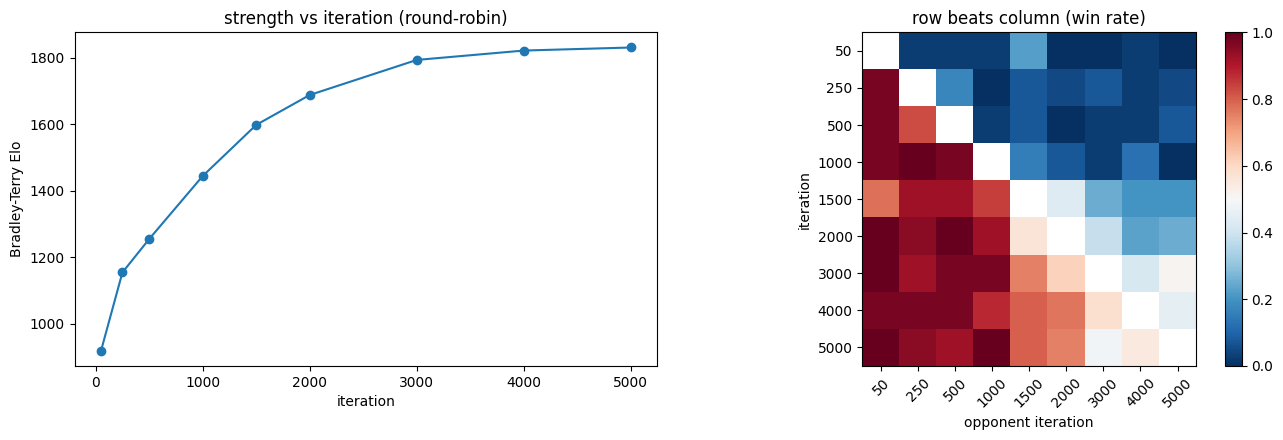

,iter,elo
0,50,918.1
1,250,1153.9
2,500,1254.3
3,1000,1443.8
4,1500,1597.6
5,2000,1687.6
6,3000,1793.0
7,4000,1821.2
8,5000,1830.4


In [16]:
S = json.loads((ROOT / "results" / "strength.json").read_text())
its = S["iters"]
elo = S["elo"]
W = np.array([[np.nan if x is None else x for x in row] for row in S["win_matrix"]])
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
axs[0].plot(its, elo, marker="o")
axs[0].set_xlabel("iteration")
axs[0].set_ylabel("Bradley-Terry Elo")
axs[0].set_title("strength vs iteration (round-robin)")
im = axs[1].imshow(W, cmap="RdBu_r", vmin=0, vmax=1)
axs[1].set_xticks(range(len(its)))
axs[1].set_xticklabels(its, rotation=45)
axs[1].set_yticks(range(len(its)))
axs[1].set_yticklabels(its)
axs[1].set_title("row beats column (win rate)")
axs[1].set_xlabel("opponent iteration")
axs[1].set_ylabel("iteration")
fig.colorbar(im, ax=axs[1], fraction=0.046)
plt.tight_layout()
plt.show()
pd.DataFrame({"iter": its, "elo": elo})

## Explored deck space — t-SNE of sampled decks, coloured by iteration

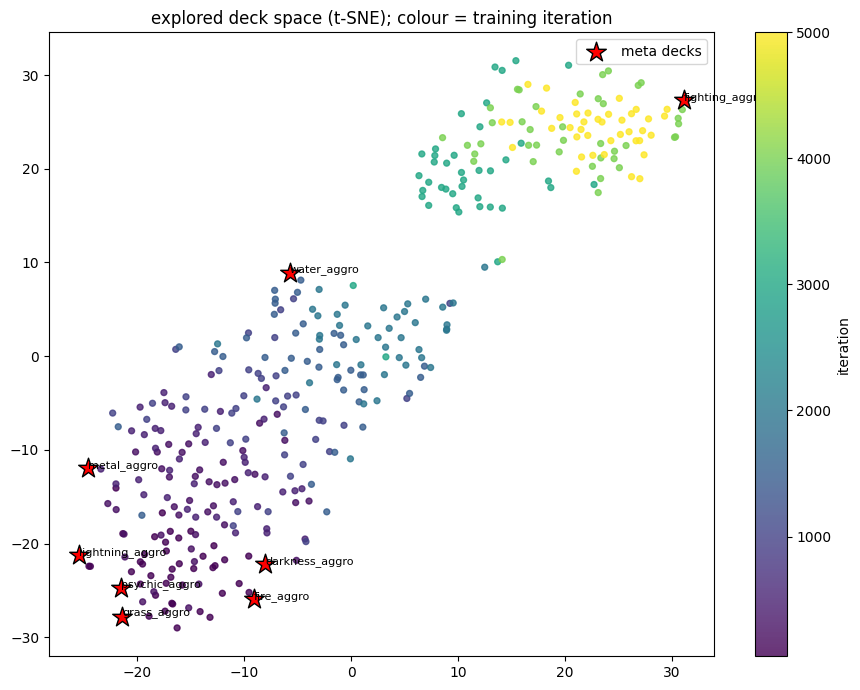

In [17]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

S = json.loads((ROOT / "results" / "strength.json").read_text())
sd = S["sampled_decks"]
metas = {p.stem: [int(x) for x in p.read_text().split()]
         for p in sorted((ROOT / "decklists").glob("*.csv"))}
vocab = sorted(
    {c for decks in sd.values() for d in decks for c in d}
    | {c for d in metas.values() for c in d}
)
col = {c: i for i, c in enumerate(vocab)}


def vec(deck):
    v = np.zeros(len(vocab))
    for c in deck:
        v[col[c]] += 1
    return v


X, it_col = [], []
for it in S["iters"]:
    for d in sd[str(it)]:
        X.append(vec(d))
        it_col.append(it)
meta_start = len(X)
for d in metas.values():
    X.append(vec(d))
X = np.array(X)
xp = PCA(n_components=min(30, X.shape[0] - 1)).fit_transform(X)
z = TSNE(n_components=2, perplexity=20, init="pca", random_state=0).fit_transform(xp)
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(z[:meta_start, 0], z[:meta_start, 1], c=it_col, cmap="viridis",
                s=18, alpha=0.8)
ax.scatter(z[meta_start:, 0], z[meta_start:, 1], c="red", marker="*", s=220,
           edgecolor="black", label="meta decks")
for k, name in enumerate(metas):
    ax.annotate(name, (z[meta_start + k, 0], z[meta_start + k, 1]), fontsize=8)
fig.colorbar(sc, ax=ax, label="iteration")
ax.legend()
ax.set_title("explored deck space (t-SNE); colour = training iteration")
plt.tight_layout()
plt.show()